In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import OneHotEncoder
from sklearn.linear_model import LinearRegression

PART A :  UNDERSTANDING THE DATASET


 Q1. Dataset Overview

In [2]:
df = pd.read_csv('agriculture_yield_dataset.csv')

In [6]:
# How many rows and columns are present?
print("Rows and Columns:", df.shape)

Rows and Columns: (1500, 8)


In [4]:
# What are the names of all columns?
print("\nColumn Names:")
print(df.columns)


Column Names:
Index(['rainfall_mm', 'temperature_c', 'fertilizer_kg', 'irrigation_hours',
       'soil_ph', 'crop_type', 'soil_type', 'yield_ton_per_hectare'],
      dtype='object')


In [5]:
# Display the first 10 records.
print("\nFirst 10 Records:")
print(df.head(10))


First 10 Records:
   rainfall_mm  temperature_c  fertilizer_kg  irrigation_hours  soil_ph  \
0        588.6           18.6          242.4               6.5      6.5   
1        772.8           34.6          247.2              10.0      6.5   
2        970.9           36.3          168.4               7.3      6.4   
3        611.7           19.0          121.7               3.7      6.0   
4        696.1           29.6          184.6               5.1      6.1   
5        831.9           28.0          190.3               2.1      6.1   
6       1023.8           32.0          108.5               6.9      6.2   
7       1142.4           18.4          241.9               4.1      7.3   
8        810.4           36.4          164.8               9.9      6.5   
9       1085.5           29.4           89.3               8.3      5.8   

  crop_type soil_type  yield_ton_per_hectare  
0     Maize     Loamy                   5.92  
1     Maize     Sandy                   6.24  
2     Wheat   

Q2. Data Types and Missing Values

In [7]:
# Check the data type of each column.
# Identify whether any missing values are present.
# If missing values exist, mention the affected columns
print(df.dtypes)

print("\nMissing Values:")
print(df.isnull().sum())


rainfall_mm              float64
temperature_c            float64
fertilizer_kg            float64
irrigation_hours         float64
soil_ph                  float64
crop_type                 object
soil_type                 object
yield_ton_per_hectare    float64
dtype: object

Missing Values:
rainfall_mm              0
temperature_c            0
fertilizer_kg            0
irrigation_hours         0
soil_ph                  0
crop_type                0
soil_type                0
yield_ton_per_hectare    0
dtype: int64


In [28]:
#If missing values exist, mention the affected columns.
missing = df.isnull().sum()

affected_columns = missing[missing > 0]

if len(affected_columns) == 0:
    print("No missing values found.")
else:
    print("Affected Columns:")
    print(affected_columns)

No missing values found.


Q3. Descriptive Statistics


In [8]:
# Which feature has the highest mean value?
print(df.describe())
print(df.mean(numeric_only=True).idxmax())

       rainfall_mm  temperature_c  fertilizer_kg  irrigation_hours  \
count  1500.000000    1500.000000    1500.000000       1500.000000   
mean    754.054667      27.749467     148.744067          5.403267   
std     255.097216       5.758101      56.990279          2.584329   
min     300.200000      18.000000      50.300000          1.000000   
25%     536.175000      22.600000      98.600000          3.200000   
50%     761.200000      27.700000     146.850000          5.400000   
75%     964.375000      32.600000     196.575000          7.600000   
max    1200.000000      38.000000     249.900000         10.000000   

           soil_ph  yield_ton_per_hectare  
count  1500.000000            1500.000000  
mean      6.759133               5.028793  
std       0.719742               0.968282  
min       5.500000               2.090000  
25%       6.100000               4.337500  
50%       6.800000               5.010000  
75%       7.400000               5.740000  
max       8.00000

In [9]:
# Which feature has the highest standard deviation?
print(df.std(numeric_only=True).idxmax())

rainfall_mm


PART B : EXPLORATORY DATA ANALYIS (EDA)


Q4. Distribution Analysis



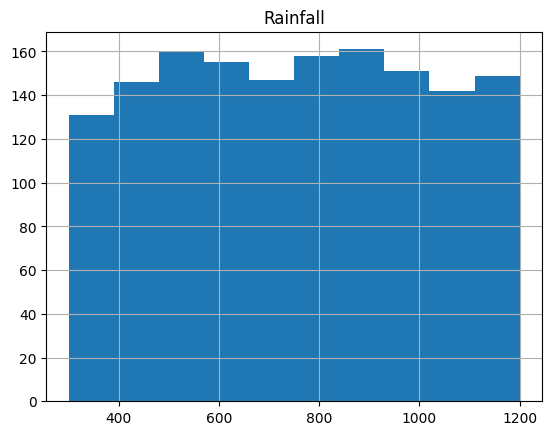

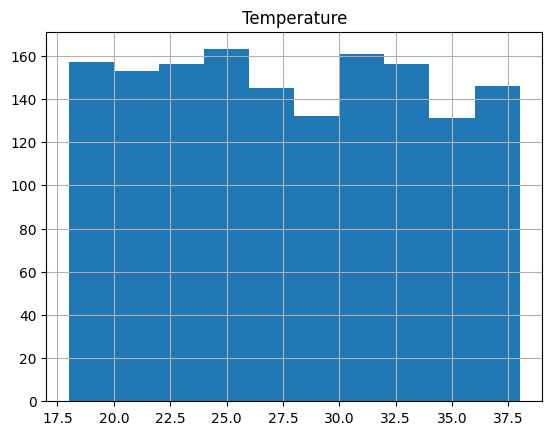

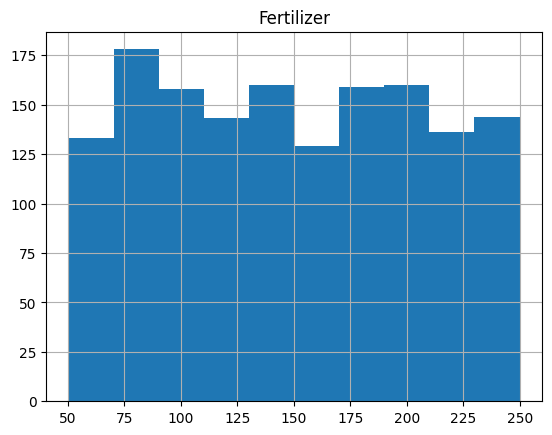

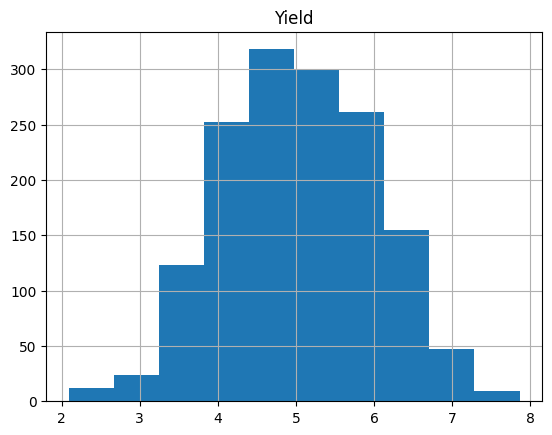

In [11]:
#Create histograms for:
 # rainfall_mm
 # temperature_c
 # fertilizer_kg
 # yield_ton_per_hectare

df['rainfall_mm'].hist()
plt.title("Rainfall")
plt.show()

df['temperature_c'].hist()
plt.title("Temperature")
plt.show()

df['fertilizer_kg'].hist()
plt.title("Fertilizer")
plt.show()

df['yield_ton_per_hectare'].hist()
plt.title("Yield")
plt.show()

Q5. Crop Type Analysis

crop_type
Cotton     311
Soybean    306
Wheat      303
Rice       293
Maize      287
Name: count, dtype: int64


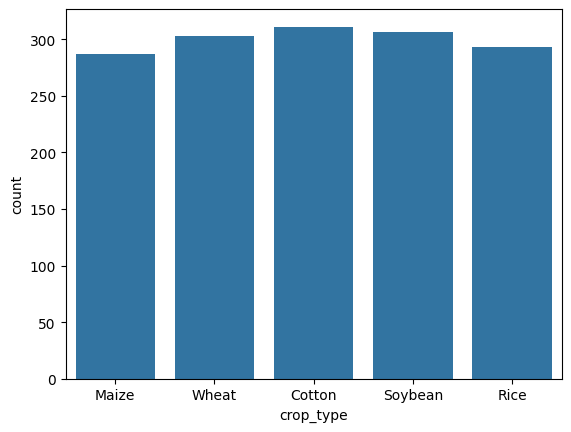

In [12]:
# Find the number of records for each crop type.
# Create a count plot (bar chart) for crop_type.
# Which crop appears most frequently?

print(df['crop_type'].value_counts())
sns.countplot(x='crop_type', data=df)
plt.show()

Q6. Soil Type Analysis

soil_type
Clay     534
Sandy    492
Loamy    474
Name: count, dtype: int64


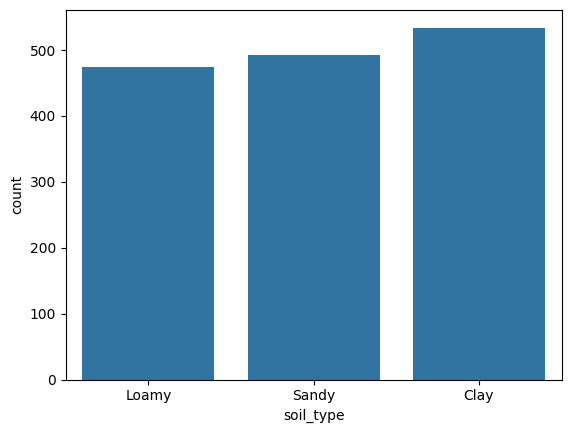

In [13]:
# Find the frequency of each soil type.
# Create a count plot for soil_type.
# Which soil type is most common?

print(df['soil_type'].value_counts())

sns.countplot(x='soil_type', data=df)
plt.show()

Q7. Yield Distribution (Create a histogram of yield_ton_per_hectare. )


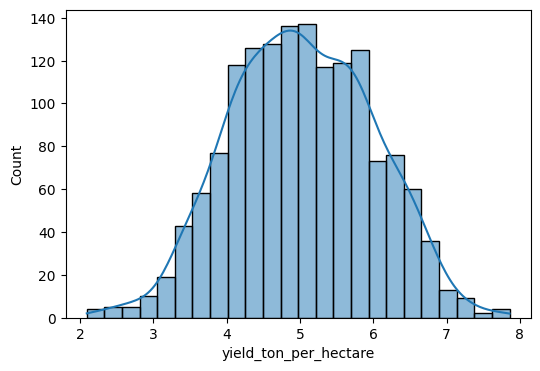

In [14]:
#Is the distribution approximately normal?
#Are there any noticeable outliers?
plt.figure(figsize=(6,4))
sns.histplot(df['yield_ton_per_hectare'], kde=True)
plt.show()

Q8. Scatter Plot Analysis

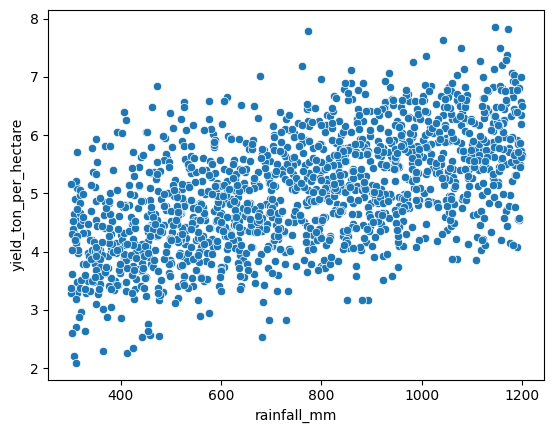

In [15]:
#1. rainfall_mm vs yield_ton_per_hectare
sns.scatterplot(
x='rainfall_mm',
y='yield_ton_per_hectare',
data=df
)
plt.show()

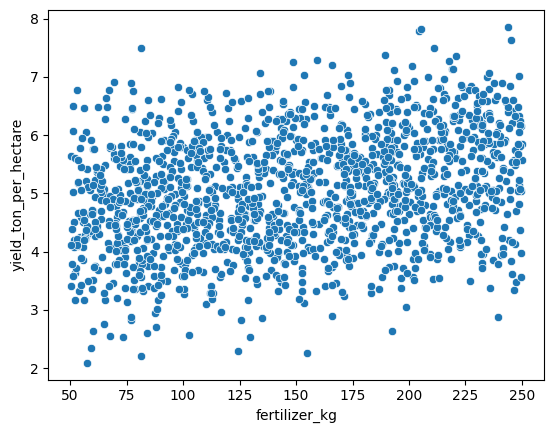

In [16]:
#2. fertilizer_kg vs yield_ton_per_hectare
sns.scatterplot(
x='fertilizer_kg',
y='yield_ton_per_hectare',
data=df
)
plt.show()

Q9. Correlation Analysis

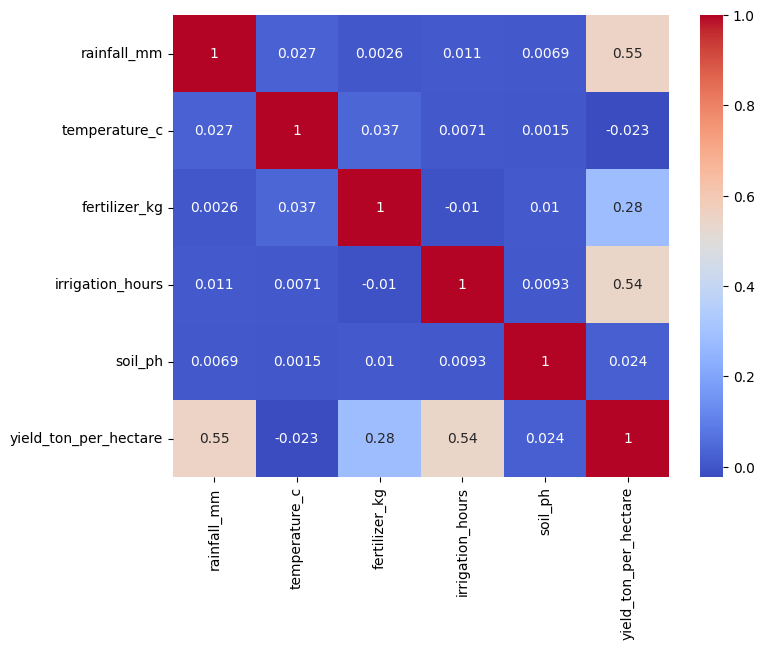

In [17]:
# Generate a correlation matrix for numerical features.
# Create a heatmap.
# Identify the top three features most correlated with crop yield.

corr = df.corr(numeric_only=True)
plt.figure(figsize=(8,6))
sns.heatmap(corr,
annot=True,
cmap='coolwarm')
plt.show()

In [29]:
#Identify the top three features most correlated with crop yield.
corr_with_yield = corr['yield_ton_per_hectare'].drop('yield_ton_per_hectare')

print(
corr_with_yield.sort_values(
ascending=False
).head(3)
)

rainfall_mm         0.553704
irrigation_hours    0.542664
fertilizer_kg       0.278043
Name: yield_ton_per_hectare, dtype: float64


Q10. Group-Based Analysis

In [18]:
#Calculate the average yield for:
# Each crop type
# Each soil type
# Each crop type and soil type combination.

print(df.groupby('crop_type')['yield_ton_per_hectare'].mean())
print(df.groupby('soil_type')['yield_ton_per_hectare'].mean())
print(df.groupby(['crop_type', 'soil_type'])['yield_ton_per_hectare'].mean())

crop_type
Cotton     4.607299
Maize      4.897143
Rice       5.494744
Soybean    5.173431
Wheat      4.989472
Name: yield_ton_per_hectare, dtype: float64
soil_type
Clay     5.134326
Loamy    5.366519
Sandy    4.588882
Name: yield_ton_per_hectare, dtype: float64
crop_type  soil_type
Cotton     Clay         4.762079
           Loamy        4.894167
           Sandy        4.150294
Maize      Clay         4.925644
           Loamy        5.290594
           Sandy        4.395765
Rice       Clay         5.642241
           Loamy        5.806944
           Sandy        5.117714
Soybean    Clay         5.247876
           Loamy        5.505294
           Sandy        4.709011
Wheat      Clay         5.007379
           Loamy        5.507363
           Sandy        4.540183
Name: yield_ton_per_hectare, dtype: float64




PART C : DATA PREPARATION


Q11. Future encoding

In [19]:
 # Identify the categorical columns.
 # Convert them into numerical form using One-Hot Encoding.
 # Display the first five rows of the transformed dataset.

 encoded_df = pd.get_dummies(
df,
columns=['crop_type','soil_type']
)

print(encoded_df.head())

   rainfall_mm  temperature_c  fertilizer_kg  irrigation_hours  soil_ph  \
0        588.6           18.6          242.4               6.5      6.5   
1        772.8           34.6          247.2              10.0      6.5   
2        970.9           36.3          168.4               7.3      6.4   
3        611.7           19.0          121.7               3.7      6.0   
4        696.1           29.6          184.6               5.1      6.1   

   yield_ton_per_hectare  crop_type_Cotton  crop_type_Maize  crop_type_Rice  \
0                   5.92             False             True           False   
1                   6.24             False             True           False   
2                   4.77             False            False           False   
3                   4.04             False             True           False   
4                   5.17              True            False           False   

   crop_type_Soybean  crop_type_Wheat  soil_type_Clay  soil_type_Loamy  \


Q12. Feature Selection

In [24]:
#Separate:
# Input features (X)
# Target variable (y) - Specify which column is being used as the target variable.

X = encoded_df.drop(
'yield_ton_per_hectare',
axis=1
)

y = encoded_df[
'yield_ton_per_hectare'
]

#The column yield_ton_per_hectare is used as the target variable (y),
#while all remaining columns are used as input features (X).



PART D : MACHINE LEARNING


Q13. Train- test split

Split the dataset into:
 80% Training Data  
 20% Testing Data


Display the shape of:
  X_train  
  X_test  
  y_train  
  y_test  

In [25]:
X_train, X_test, y_train, y_test = train_test_split(
X,
y,
test_size=0.2,
random_state=42
)

print(X_train.shape)
print(X_test.shape)
print(y_train.shape)
print(y_test.shape)

(1200, 13)
(300, 13)
(1200,)
(300,)


Q14. Linear Regression Model

In [26]:
# Train a Linear Regression model.
# Display the model coefficients and intercept.


model = LinearRegression()

model.fit(
X_train,
y_train
)

print("Intercept:")
print(model.intercept_)

coef_df = pd.DataFrame({
    'Feature': X.columns,
    'Coefficient': model.coef_
})

print(coef_df)

Intercept:
1.9111026182800726
              Feature  Coefficient
0         rainfall_mm     0.002035
1       temperature_c    -0.009175
2       fertilizer_kg     0.004978
3    irrigation_hours     0.198327
4             soil_ph     0.004901
5    crop_type_Cotton    -0.386623
6     crop_type_Maize    -0.147693
7      crop_type_Rice     0.477369
8   crop_type_Soybean     0.095096
9     crop_type_Wheat    -0.038149
10     soil_type_Clay     0.062653
11    soil_type_Loamy     0.365627
12    soil_type_Sandy    -0.428280


In [27]:
# Which feature has the highest positive coefficient?
print(
coef_df.sort_values(
by='Coefficient',
ascending=False
).head(1)
)

          Feature  Coefficient
7  crop_type_Rice     0.477369
